In [29]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms,align
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [14]:
# Load the trajectory and topology files
u = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.prmtop', '/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/Analysis/6-md_auto.nc')
#ref = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.prmtop','/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.pdb')
len(u.trajectory)

10000

In [15]:
# Calculate RMSD
rmsd = rms.RMSD(u, u, ref_frame=0, select='backbone')
rmsd.run()

# Convert frames to time
time_step = 0.1  # time step in nanoseconds
time = np.arange(len(rmsd.rmsd)) * time_step

# Calculate average RMSD
average_rmsd = np.mean(rmsd.rmsd[:, 2])

# Create a DataFrame with time and RMSD values
rmsd_df = pd.DataFrame({
    'Time (ns)': time,
    'RMSD (Å)': rmsd.rmsd[:, 2]
})

In [16]:

# Print the DataFrame and average RMSD
print("RMSD DataFrame:")
print(rmsd_df)
print(f"\nAverage RMSD: {average_rmsd:.2f} Å")

RMSD DataFrame:
      Time (ns)      RMSD (Å)
0           0.0  2.930051e-07
1           0.1  8.392854e-01
2           0.2  8.311177e-01
3           0.3  9.317016e-01
4           0.4  8.391863e-01
...         ...           ...
9995      999.5  2.016767e+00
9996      999.6  2.123876e+00
9997      999.7  2.039173e+00
9998      999.8  2.164509e+00
9999      999.9  2.072564e+00

[10000 rows x 2 columns]

Average RMSD: 1.67 Å


In [35]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

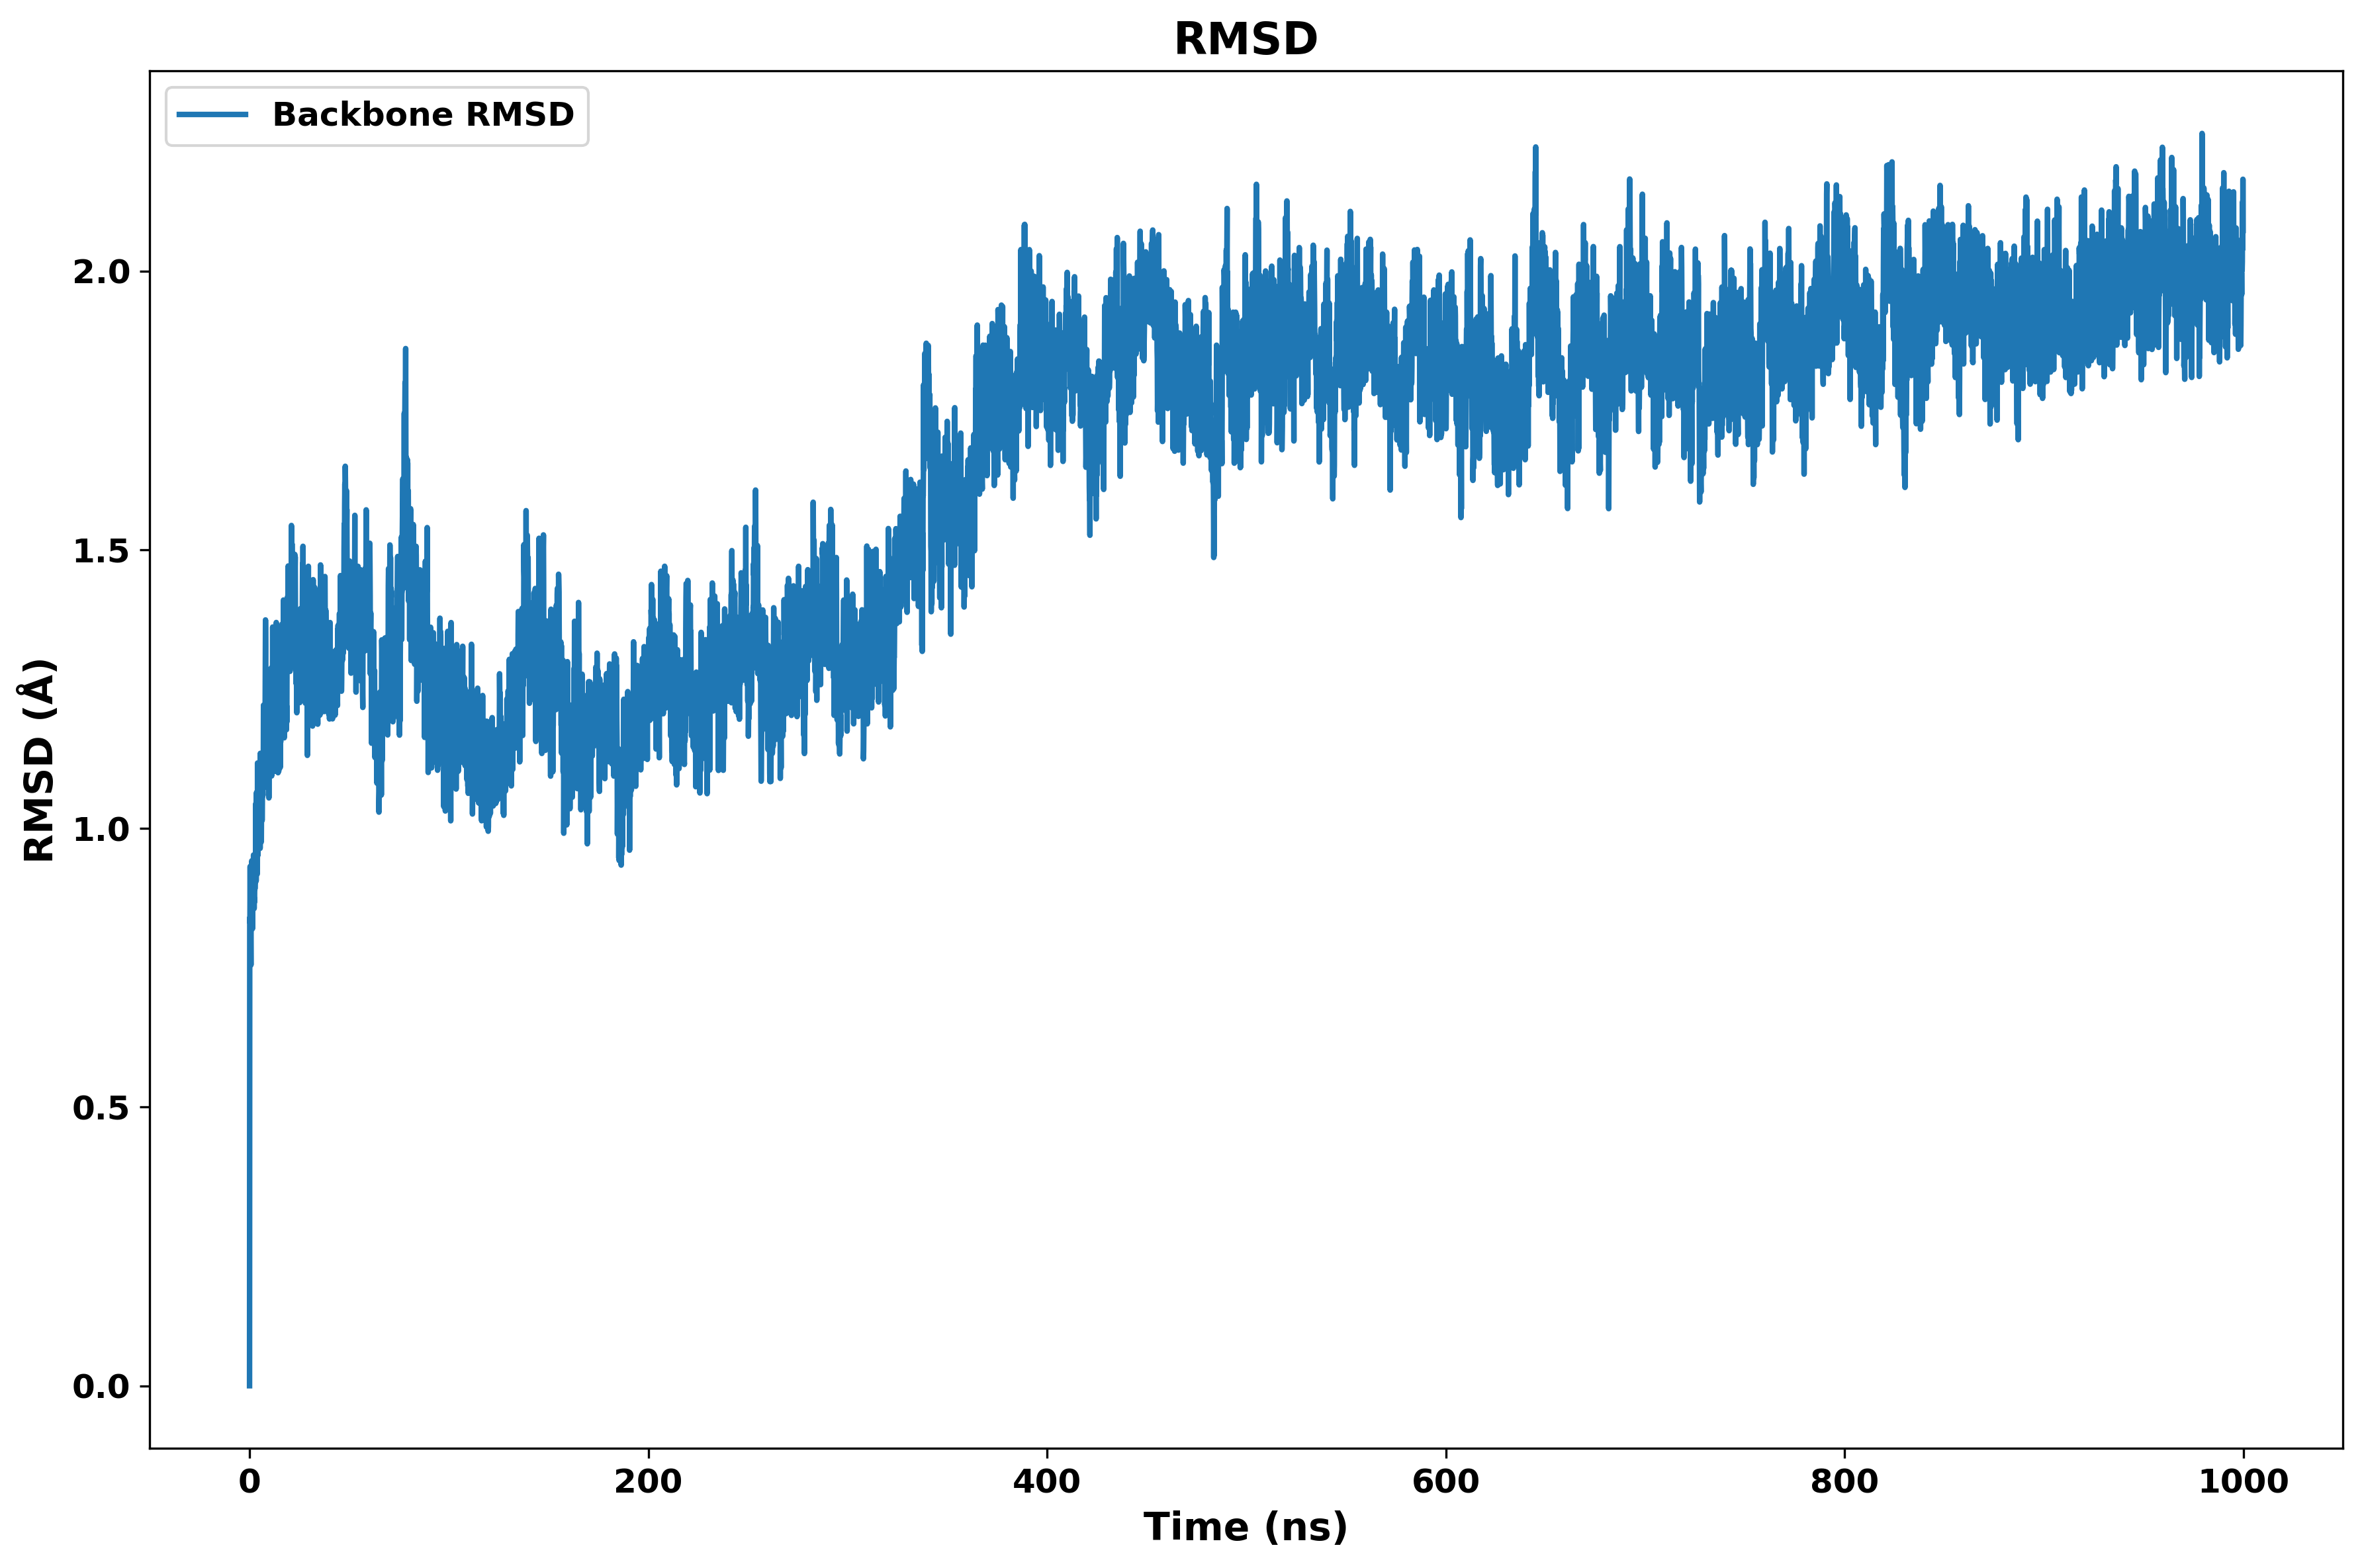

In [36]:

# Plot RMSD with high quality settings
plt.figure(figsize=(12, 8), dpi=300)  # Set figure size and resolution
plt.plot(time, rmsd.rmsd[:, 2], label='Backbone RMSD', linewidth=2)
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('RMSD (Å)', fontsize=14)
plt.title('RMSD', fontsize=16)
plt.legend(fontsize=12)
plt.grid(False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
# Select the backbone atoms for alignment
backbone = u.select_atoms('backbone')

# Align the trajectory to the first frame
aligner = align.AlignTraj(u, u, select='backbone', in_memory=True).run()

# Select the C-alpha atoms for RMSF calculation
calphas = u.select_atoms('name CA or name FE or name O1')

# Calculate the average positions of the selected atoms
avg_positions = calphas.positions.copy()
for ts in u.trajectory:
    avg_positions += calphas.positions
avg_positions /= len(u.trajectory)

# Calculate RMSF
rmsf = np.zeros(calphas.n_atoms)
for ts in u.trajectory:
    rmsf += np.sum((calphas.positions - avg_positions)**2, axis=1)
rmsf = np.sqrt(rmsf / len(u.trajectory))

# Create a DataFrame with residue IDs and RMSF values
residues = [res.resid for res in calphas.residues]
rmsf_df = pd.DataFrame({
    'Residue': residues,
    'RMSF (Å)': rmsf
})

# Print the DataFrame
print("RMSF DataFrame:")
print(rmsf_df)

RMSF DataFrame:
     Residue  RMSF (Å)
0          1  7.711582
1          2  5.166102
2          3  3.428574
3          4  1.342737
4          5  1.079060
..       ...       ...
340      341  2.161836
341      342  3.800942
342      343  0.608025
343      344  0.751534
344      345  1.495013

[345 rows x 2 columns]


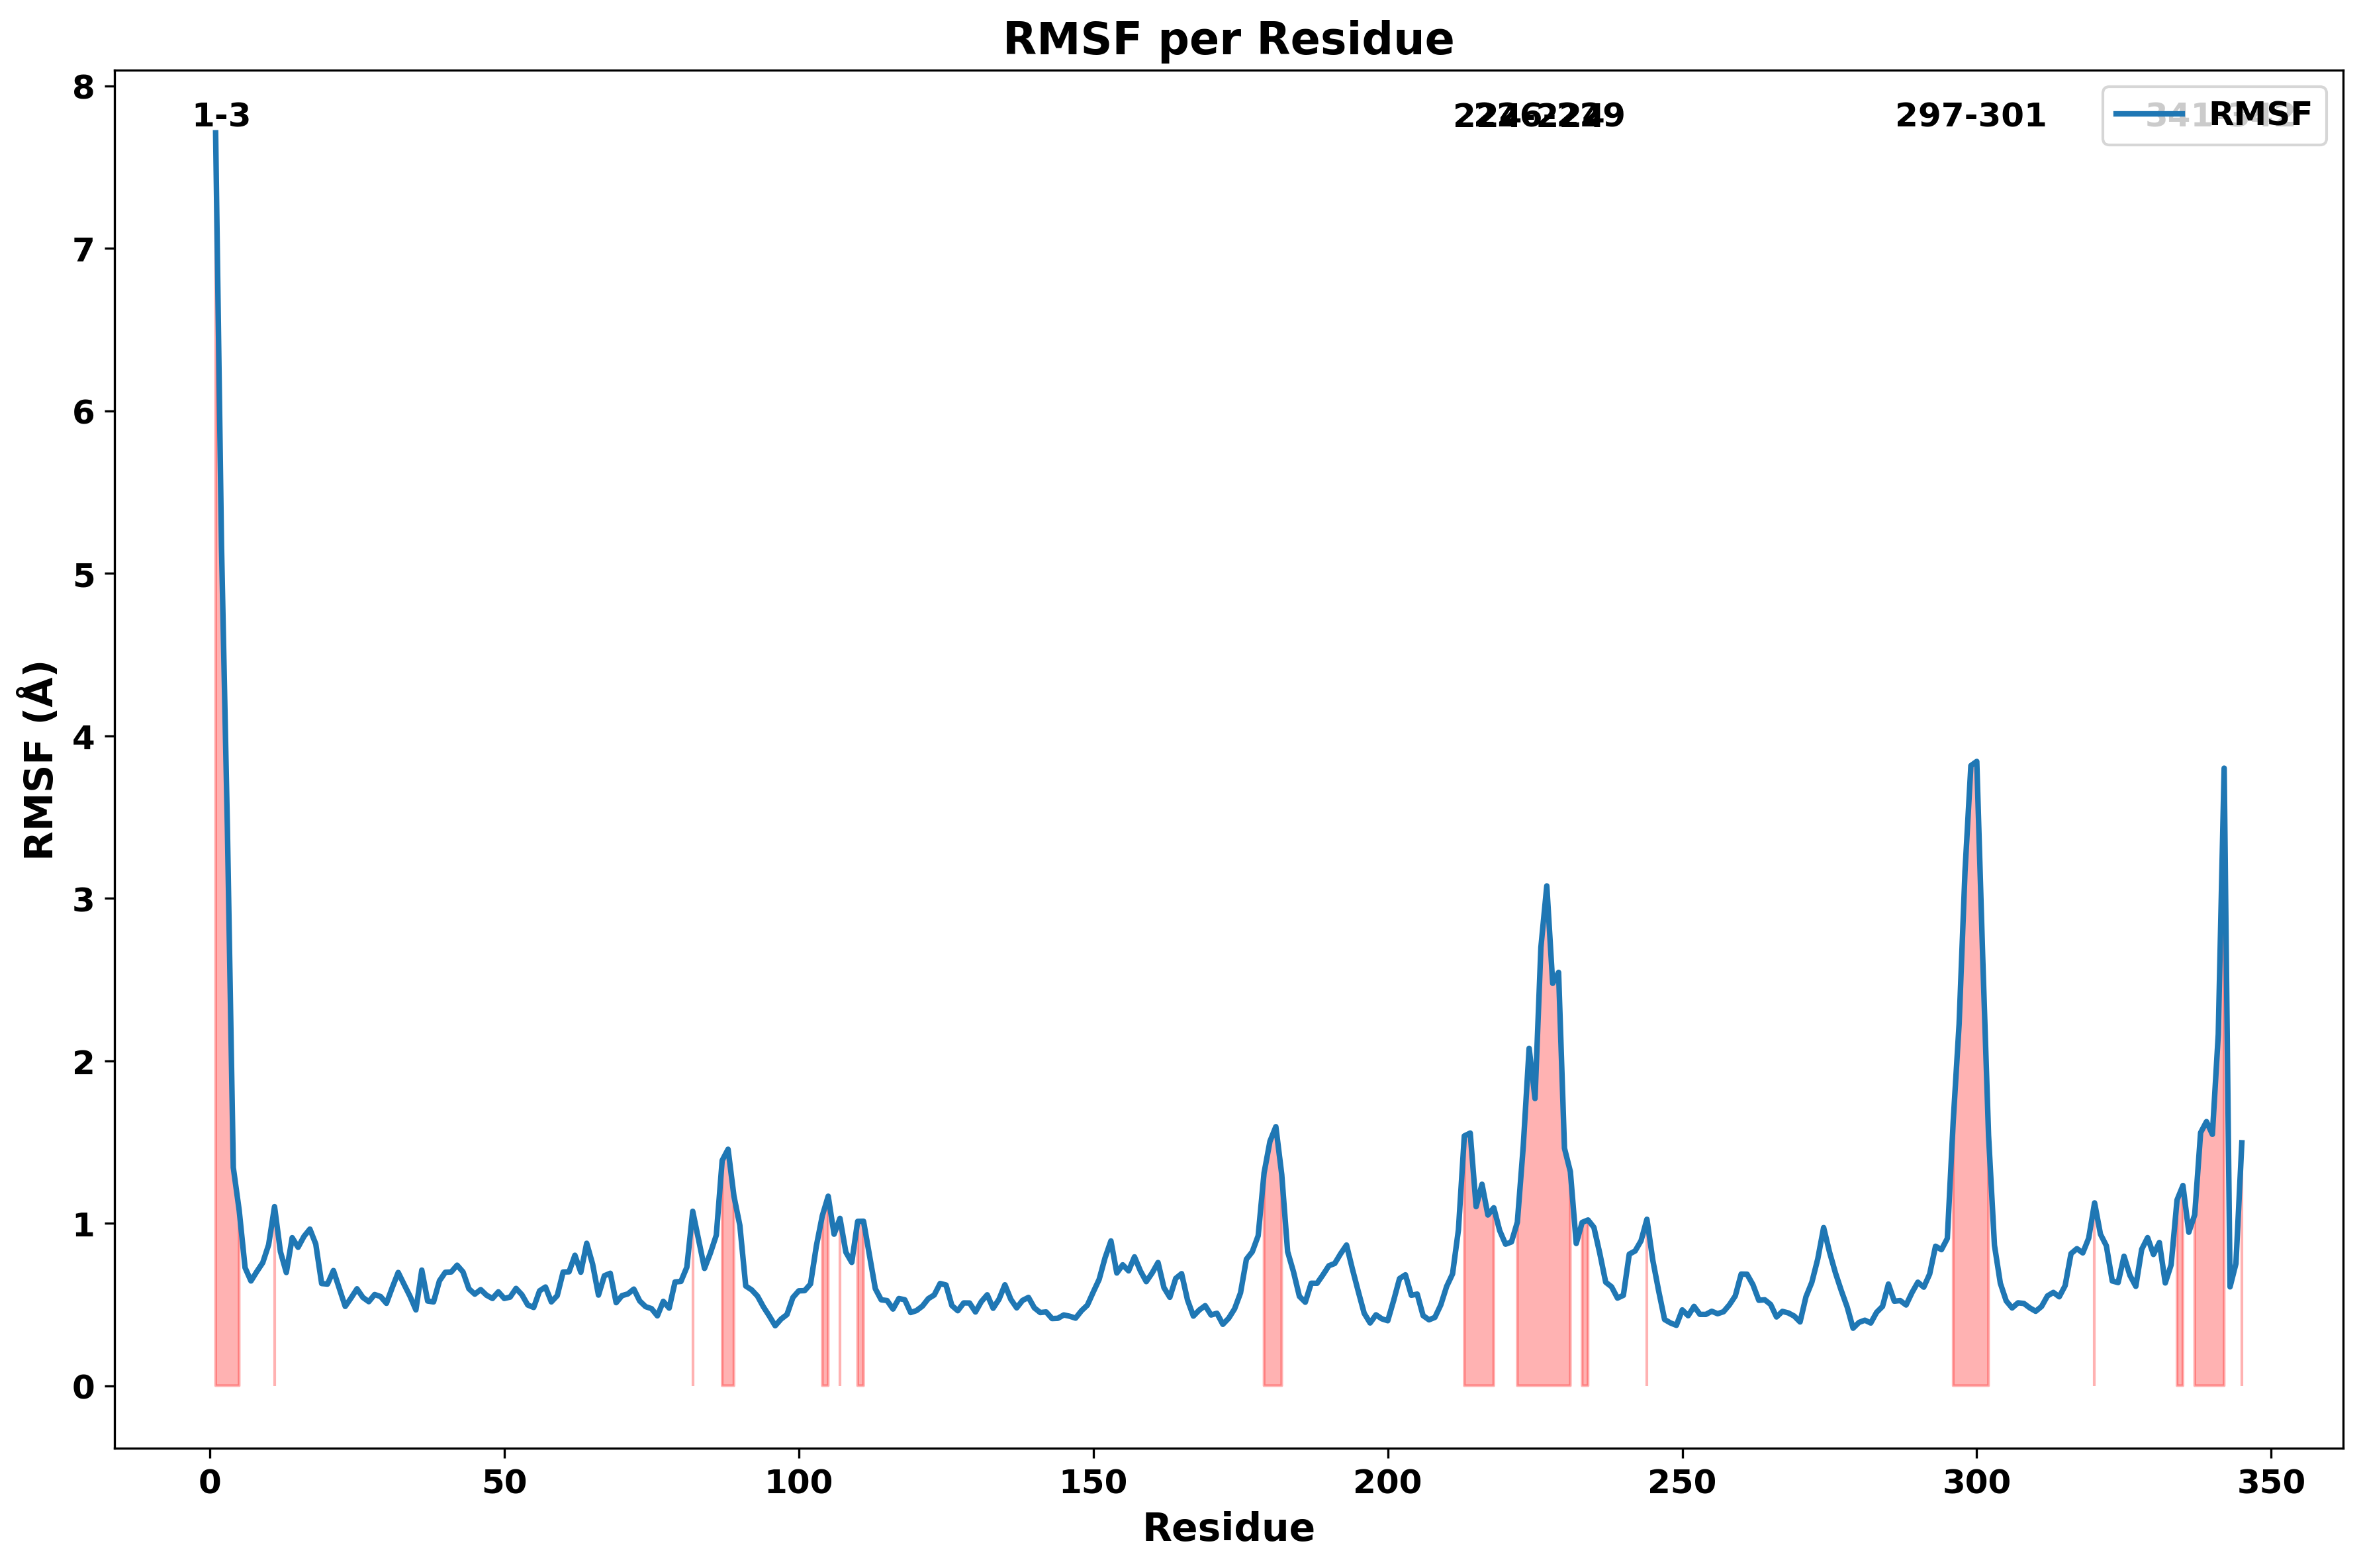

In [41]:
# Plot RMSF with high quality settings
plt.figure(figsize=(12, 8), dpi=300)  # Set figure size and resolution
plt.plot(residues, rmsf, label='RMSF', linewidth=2)
plt.xlabel('Residue')
plt.ylabel('RMSF (Å)')
plt.title('RMSF per Residue')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.fill_between(residues, rmsf, where=(rmsf > 1), color='red', alpha=0.3)
ranges = []
start = None
for i, value in enumerate(rmsf):
    if value > 2 and start is None:
        start = residues[i]
    elif value <= 2 and start is not None:
        end = residues[i-1]
        ranges.append((start, end))
        start = None
if start is not None:
    ranges.append((start, residues[-1]))
for (start, end) in ranges:
    plt.text((start + end) / 2, max(rmsf), f'{start}-{end}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()  

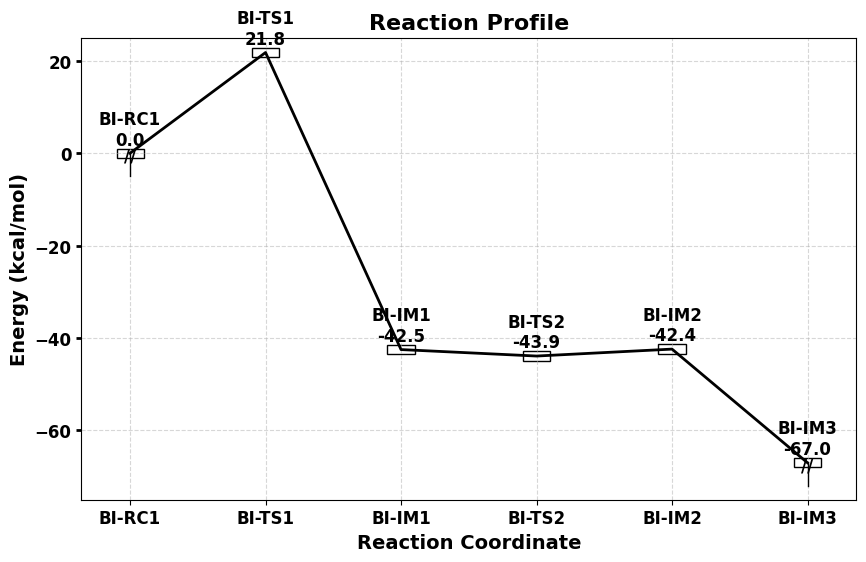

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Define reaction coordinates and corresponding energies
states = ['BI-RC1', 'BI-TS1', 'BI-IM1', 'BI-TS2', 'BI-IM2', 'BI-IM3']
energies = [0.0, 21.8, -42.5, -43.9, -42.4, -67.0]

# Plot settings
fig, ax = plt.subplots(figsize=(10, 6))

# Plot energy profile with lines connecting states
ax.plot(states, energies, 'k-', linewidth=2)

# Define rectangle properties
rect_width = 0.2
rect_height = 2.0

# Add rectangles at each state
for i, (state, energy) in enumerate(zip(states, energies)):
    # Draw the rectangle
    rect = Rectangle((i - rect_width/2, energy - rect_height/2), rect_width, rect_height,
                     linewidth=1, edgecolor='k', facecolor='none')
    ax.add_patch(rect)
    # Add text annotations for each state
    ax.text(state, energy + 1, f'{state}\n{energy:.1f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add breaks (represented by '//' symbol) in the plot for clarity
# Vertical line for the first break
ax.plot(['BI-RC1', 'BI-RC1'], [0, -5], 'k', linewidth=1)
# Vertical line for the second break
ax.plot(['BI-IM3', 'BI-IM3'], [-67, -72], 'k', linewidth=1)

# Adding the break lines (//)
ax.text('BI-RC1', -2.5, '//', ha='center',
        va='bottom', fontsize=12, fontweight='bold')
ax.text('BI-IM3', -69.5, '//', ha='center',
        va='bottom', fontsize=12, fontweight='bold')

# Set plot labels and title
ax.set_xlabel('Reaction Coordinate', fontsize=14, fontweight='bold')
ax.set_ylabel('Energy (kcal/mol)', fontsize=14, fontweight='bold')
ax.set_title('Reaction Profile', fontsize=16, fontweight='bold')

# Customize ticks
ax.set_xticks(states)
ax.set_xticklabels(states, fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=12, width=2)

# Set y-axis limit
ax.set_ylim(-75, 25)

# Show grid
ax.grid(True, linestyle='--', alpha=0.5)

# Save the plot in high resolution
plt.savefig('reaction_profile_high_quality.png',
            format='png', dpi=300)  # PNG format
plt.savefig('reaction_profile_high_quality.pdf',
            format='pdf', dpi=300)  # PDF format
plt.savefig('reaction_profile_high_quality.svg',
            format='svg', dpi=300)  # SVG format

# Show the plot
plt.show()